# 00 MuJoCo 四脚の動作確認

## 背景

このリポジトリの学習は、完成した歩行器から始めない。最初に必要なのは、**シミュレータが四脚を1体置いて、時間を進められる**ことである。制御の正しさはまだ問わない。

実施は MuJoCo の Go2 である（[00 README](../docs/block-curriculum/00_README.md) §7）。Gazebo では走らせない。

## 目的

- `src/` のプラントを import して、関節トルク 0 で数秒進める
- 接地反力（実接触）と胴体への合力、重力 \(mg\) を矢印にした GIF が Notebook に残る
- 重力で潰れる／床に当たる様子が見える

この段に予測最適化は無い。指令 GRF もまだ無い。矢印は **MuJoCo が返した実接触** である。

## 数式

全身は概念的に次である（詳細は [qpympc-study/01](../docs/qpympc-study/01_MuJoCo_Go2_Plant_Model.md)）。

\[
M(q)\ddot q + h(q,\dot q) = S^\top \tau + J_c(q)^\top \lambda
\]

本 Notebook では \(\tau = 0\)。\(\lambda\) は接触ソルバーの実接触力。胴体への合力の接触分は \(\sum_i \lambda_i\)。重力は \(mg\)（下向き）。

## 図

```
tau = 0
    |
    v
+-----------+     lambda (4 x 3)     +----------------+
| MuJoCo    | ---------------------> | 足の矢印        |
| Go2 step  |                        | 赤: 合力        |
+-----------+                        | 灰: mg          |
    |                                +----------------+
    +----> GIF を Notebook に入れる
```

脚色: FL 青、FR 緑、RL 橙、RR 紫。


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/docs/block-curriculum/notebook/assets/00_mujoco_go2_demo.gif 2100560 bytes


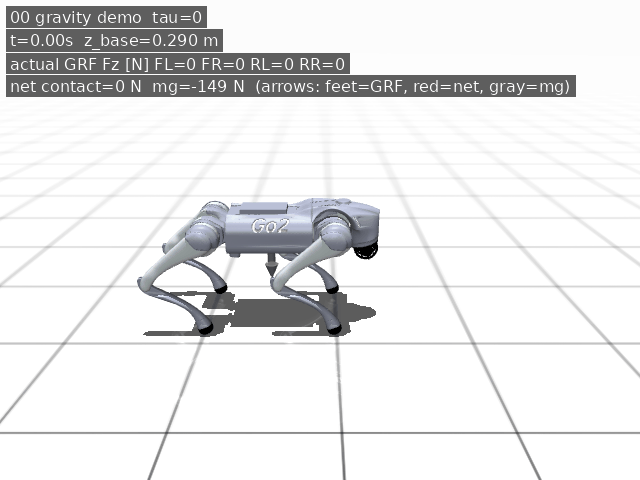

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.demo_gravity import run_gravity_demo

gif = Path("assets/00_mujoco_go2_demo.gif")
path = run_gravity_demo(gif)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 結果の読み方

- 灰矢印（\(mg\)）は下向きで、質量が変わらなければ長さはほぼ一定
- 赤矢印は実接触の合力。空中ではほぼ 0、着地後に上向き成分が出る
- 足の矢印は指令ではない。まだ EqualShare も MPC も無い
- 次はトルク飽和と、体重を支える力である（フェーズ 0 の 2–3）
